# 1. Tải dữ liệu từ github về drive (Opt.)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/nguyenhuuphuc11052005/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem.git

Cloning into 'Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 615 (delta 0), reused 12 (delta 0), pack-reused 599 (from 2)
Receiving objects: 100% (615/615), 84.86 MiB | 16.97 MiB/s, done.
Resolving deltas: 100% (342/342), done.


# 2. Truy cập vào folder

In [ ]:
%cd /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/

/content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem


# 3. Tải thư viện cần thiết

In [ ]:
# tải thư viện cần thiết
!pip install -r requirement.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 7.9 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=6cf2375513fb773e14ca310b2cb077a42cf5d5c116bea0a52b7b9c63bde539e3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


# 4. Tải dữ liệu ảnh từ kaggle (Opt.)
đường dẫn đến file ảnh: /root/.cache/kagglehub/datasets/jeffaudi/coco-2014-dataset-for-yolov3/4

In [ ]:
# tải file ảnh
import kagglehub
path = kagglehub.dataset_download("jeffaudi/coco-2014-dataset-for-yolov3")

100%|██████████| 25.0G/25.0G [10:49<00:00, 41.3MB/s]

Extracting files...


# 5. Chia file train caption thành train, val và test


In [ ]:
# # up file captions lên đây
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# import json
# import random
# import os

# def create_coco_splits(original_json_path, output_dir, total_images=50000, train_ratio=0.8, val_ratio=0.1):
#     print("Đang nạp file JSON gốc. Vui lòng đợi (có thể mất khoảng 1-2 phút)...")
#     with open(original_json_path, 'r') as f:
#         coco_data = json.load(f)

#     print("Đang xử lý dữ liệu...")
#     # 1. Lấy danh sách tất cả các ảnh và xáo trộn ngẫu nhiên
#     images = coco_data['images']
#     random.seed(42) # Cố định seed để nếu chạy lại vẫn ra đúng tập này
#     random.shuffle(images)

#     # 2. Cắt lấy đúng số lượng ảnh mong muốn (50.000)
#     subset_images = images[:total_images]

#     # 3. Tính toán số lượng cho từng tập
#     train_size = int(total_images * train_ratio)
#     val_size = int(total_images * val_ratio)

#     train_images = subset_images[:train_size]
#     val_images = subset_images[train_size:train_size + val_size]
#     test_images = subset_images[train_size + val_size:]

#     print(f"Đã chia: Train ({len(train_images)}), Val ({len(val_images)}), Test ({len(test_images)})")

#     # 4. Tạo dictionary map image_id với thông tin ảnh để tra cứu nhanh
#     def get_annotations_for_images(image_list):
#         img_ids = {img['id'] for img in image_list}
#         # Lọc ra các caption thuộc về những ảnh trong danh sách
#         anns = [ann for ann in coco_data['annotations'] if ann['image_id'] in img_ids]
#         return anns

#     # 5. Hàm lưu file JSON mới giữ nguyên cấu trúc COCO
#     def save_split(img_list, filename):
#         anns = get_annotations_for_images(img_list)
#         split_data = {
#             "info": coco_data.get("info", {}),
#             "licenses": coco_data.get("licenses", []),
#             "images": img_list,
#             "annotations": anns
#         }

#         out_path = os.path.join(output_dir, filename)
#         with open(out_path, 'w') as f:
#             json.dump(split_data, f)
#         print(f"Đã lưu thành công: {out_path} (Gồm {len(img_list)} ảnh và {len(anns)} captions)")

#     # 6. Tạo thư mục đầu ra và lưu các file
#     os.makedirs(output_dir, exist_ok=True)
#     save_split(train_images, "subset_train.json")
#     save_split(val_images, "subset_val.json")
#     save_split(test_images, "subset_test.json")

# # HƯỚNG DẪN CHẠY:
# # Sửa đường dẫn bên dưới cho khớp với vị trí bạn lưu file
# original_path = "captions_train2014.json"# file caption tự upload lên Colab
# output_folder = "/content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/"

# create_coco_splits(original_path, output_folder)

# 6. Đánh giá chỉ số của mô hình

In [ ]:
import os
import json
import torch
import torch.nn as nn
import argparse
import torchvision.transforms as transforms
# import torch.distributed as dist
import warnings
warnings.filterwarnings("ignore")
import pickle
# from src.data.vocabulary import Vocabulary
from src.data.dataset import get_loader, get_transforms
from src.models.encoder import ResNet50Encoder,ResNet50SpatialEncoder
from src.models.decoder_lstm import LSTMDecoder
from src.models.m2_transformer import M2TransformerDecoder
from src.models.vit_transformer import ViTCaptioningModel
from src.training.train import train_model
from src.utils import set_seed, load_config


## Đánh giá 3 mô hình bằng beam search với beam_size=5

In [ ]:
!python eval.py \
  --config configs/baseline_lstm.yaml \
  --checkpoint experiments/checkpoints/baseline_lstm_run1/best_model.pth \
  --model_type lstm \
  --decode_mode beam_search \
  --beam_size 5 \
  --images_path /root/.cache/kagglehub/datasets/jeffaudi/coco-2014-dataset-for-yolov3/versions/4/coco2014/images/train2014 \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 16:51:31,085 - INFO - Start evaluation
2026-05-29 16:51:31,087 - INFO - Model type: lstm
2026-05-29 16:51:31,090 - INFO - Decode mode: beam_search
2026-05-29 16:51:31,091 - INFO - Beam size: 5
2026-05-29 16:51:31,092 - INFO - Checkpoint: experiments/checkpoints/baseline_lstm_run1/best_model.pth
2026-05-29 16:51:31,092 - INFO - Images path: /root/.cache/kagglehub/datasets/jeffaudi/coco-2014-dataset-for-yolov3/versions/4/coco2014/images/train2014
2026-05-29 16:51:31,093 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/baseline_lstm.ya

In [ ]:
!python eval.py \
  --config configs/m2_transformer.yaml \
  --checkpoint experiments/checkpoints/m2_transformer_run1/best_model.pth \
  --model_type m2_transformer \
  --decode_mode beam_search \
  --beam_size 5 \
  --images_path /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/ \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 17:48:20,922 - INFO - Start evaluation
2026-05-29 17:48:20,923 - INFO - Model type: m2_transformer
2026-05-29 17:48:20,924 - INFO - Decode mode: beam_search
2026-05-29 17:48:20,925 - INFO - Beam size: 5
2026-05-29 17:48:20,925 - INFO - Checkpoint: experiments/checkpoints/m2_transformer_run1/best_model.pth
2026-05-29 17:48:20,925 - INFO - Images path: /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/
2026-05-29 17:48:20,925 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/m2_transformer.yaml
loading annotations in

In [ ]:
!python eval.py \
  --config configs/vit_transformer.yaml \
  --checkpoint experiments/checkpoints/vit_transformer_v1/best_model.pth \
  --model_type vit_transformer \
  --decode_mode beam_search \
  --beam_size 5 \
  --images_path /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/ \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 18:28:19,809 - INFO - Start evaluation
2026-05-29 18:28:19,831 - INFO - Model type: vit_transformer
2026-05-29 18:28:19,838 - INFO - Decode mode: beam_search
2026-05-29 18:28:19,839 - INFO - Beam size: 5
2026-05-29 18:28:19,839 - INFO - Checkpoint: experiments/checkpoints/vit_transformer_v1/best_model.pth
2026-05-29 18:28:19,839 - INFO - Images path: /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/
2026-05-29 18:28:19,839 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/vit_transformer.yaml
loading annotations i

## Bảng so sánh với thuật toán Beam Search với beam=5
| Mô hình / Lần đánh giá | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 | METEOR | ROUGE-L | CIDEr |
|---|---:|---:|---:|---:|---:|---:|---:|
| LSTM | 0.57665 | 0.36313 | 0.23501 | 0.15879 | 0.37659 | 0.42245 | 0.41054 |
| M2-TRANSFORMER | 0.67494 | 0.47550 | 0.33515 | 0.23727 | 0.42207 | 0.48336 | 0.68592 |
| VIT-TRANSFORMER | 0.67634 | 0.47943 | 0.33990 | 0.24177 | 0.42369 | 0.48763 | 0.67995 |

## Đánh giá 3 mô hình bằng greedy search

In [ ]:
!python eval.py \
  --config configs/baseline_lstm.yaml \
  --checkpoint experiments/checkpoints/baseline_lstm_run1/best_model.pth \
  --model_type lstm \
  --decode_mode greedy \
  --images_path /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/ \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 18:53:19,289 - INFO - Start evaluation
2026-05-29 18:53:19,290 - INFO - Model type: lstm
2026-05-29 18:53:19,292 - INFO - Decode mode: greedy
2026-05-29 18:53:19,292 - INFO - Beam size: 5
2026-05-29 18:53:19,293 - INFO - Checkpoint: experiments/checkpoints/baseline_lstm_run1/best_model.pth
2026-05-29 18:53:19,293 - INFO - Images path: /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/
2026-05-29 18:53:19,293 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/baseline_lstm.yaml
Downloading: "https://download.pytorch.

In [ ]:
!python eval.py \
  --config configs/m2_transformer.yaml \
  --checkpoint experiments/checkpoints/m2_transformer_run1/best_model.pth \
  --model_type m2_transformer \
  --decode_mode greedy \
  --images_path /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/ \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 18:57:34,848 - INFO - Start evaluation
2026-05-29 18:57:34,850 - INFO - Model type: m2_transformer
2026-05-29 18:57:34,851 - INFO - Decode mode: greedy
2026-05-29 18:57:34,852 - INFO - Beam size: 5
2026-05-29 18:57:34,853 - INFO - Checkpoint: experiments/checkpoints/m2_transformer_run1/best_model.pth
2026-05-29 18:57:34,853 - INFO - Images path: /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/
2026-05-29 18:57:34,854 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/m2_transformer.yaml
loading annotations into me

In [ ]:
!python eval.py \
  --config configs/vit_transformer.yaml \
  --checkpoint experiments/checkpoints/vit_transformer_v1/best_model.pth \
  --model_type vit_transformer \
  --decode_mode greedy \
  --images_path /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/ \
  --ann_file /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-29 19:07:14,060 - INFO - Start evaluation
2026-05-29 19:07:14,061 - INFO - Model type: vit_transformer
2026-05-29 19:07:14,062 - INFO - Decode mode: greedy
2026-05-29 19:07:14,062 - INFO - Beam size: 5
2026-05-29 19:07:14,063 - INFO - Checkpoint: experiments/checkpoints/vit_transformer_v1/best_model.pth
2026-05-29 19:07:14,063 - INFO - Images path: /kaggle/input/coco-2014-dataset-for-yolov3/coco2014/images/train2014/
2026-05-29 19:07:14,064 - INFO - Annotation file: /content/drive/MyDrive/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/ms_coco/annotations/subset_test.json
[*] Đã cố định Random Seed: 42
-> Đã load Vocab với 8853 từ.
[*] Đã nạp cấu hình từ configs/vit_transformer.yaml
loading annotations into m

## Bảng so sánh với thuật toán Greedy Search
| Mô hình / Lần đánh giá | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 | METEOR | ROUGE-L | CIDEr |
|---|---:|---:|---:|---:|---:|---:|---:|
| LSTM | 0.60978 | 0.37891 | 0.23468 | 0.14998 | 0.36411 | 0.42591 | 0.40780 |
| M2-TRANSFORMER | 0.67025 | 0.46670 | 0.31889 | 0.21522 | 0.42835 | 0.48125 | 0.65429 |
| VIT-TRANSFORMER | 0.66157 | 0.46007 | 0.31378 | 0.21359 | 0.41737 | 0.47556 | 0.63224 |

# 7. Tổng hợp kết quả

In [ ]:
import pandas as pd

data = [
    ["LSTM", "Greedy Search", 0.14998, 0.36411, 0.42591, 0.40780],
    ["LSTM", "Beam Search",   0.15879, 0.37659, 0.42245, 0.41054],
    ["ViT",  "Greedy Search", 0.21522, 0.42835, 0.48125, 0.65429],
    ["ViT",  "Beam Search",   0.23727, 0.42207, 0.48336, 0.68592],
    ["M2",   "Greedy Search", 0.21359, 0.41737, 0.47556, 0.63224],
    ["M2",   "Beam Search",   0.24177, 0.42369, 0.48763, 0.67995],
]

df = pd.DataFrame(data, columns=["Model", "Decoding", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"])
print(df)

  Model       Decoding   BLEU-4   METEOR  ROUGE-L    CIDEr
0  LSTM  Greedy Search  0.14998  0.36411  0.42591  0.40780
1  LSTM    Beam Search  0.15879  0.37659  0.42245  0.41054
2   ViT  Greedy Search  0.21522  0.42835  0.48125  0.65429
3   ViT    Beam Search  0.23727  0.42207  0.48336  0.68592
4    M2  Greedy Search  0.21359  0.41737  0.47556  0.63224
5    M2    Beam Search  0.24177  0.42369  0.48763  0.67995


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metric_comparison(df: pd.DataFrame, metric: str):
  """
  Vẽ biểu đồ cột nhóm so sánh Greedy Search và Beam Search
  trên từng mô hình đối với một metric cụ thể.
  :param df: DataFrame chứa các cột: Model, Decoding và các metric.
  :param metric: Tên metric cần vẽ, ví dụ: 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr'.
  """

  # Lấy danh sách mô hình theo thứ tự xuất hiện
  models = df["Model"].unique()

  # Lấy điểm Greedy Search theo từng mô hình
  greedy_scores = (df[df["Decoding"] == "Greedy Search"].set_index("Model").loc[models, metric].values)

  # Lấy điểm Beam Search theo từng mô hình
  beam_scores = (df[df["Decoding"] == "Beam Search"].set_index("Model").loc[models, metric].values)

  # Vị trí các nhóm cột trên trục x
  x = np.arange(len(models))

  # Giảm width để cột nhỏ hơn
  width = 0.25

  plt.figure(figsize=(8, 5))
  bars1 = plt.bar(x - width / 2, greedy_scores, width=0.25, label="Greedy Search", color="#6495ed")
  bars2 = plt.bar(x + width / 2, beam_scores, width, label="Beam Search", color="#f08080")

  # Hiển thị giá trị trên đầu cột
  for bar in bars1:
      height = bar.get_height()
      plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}",
                ha="center", va="bottom", fontsize=9)

  for bar in bars2:
      height = bar.get_height()
      plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}",
                ha="center", va="bottom", fontsize=9)

  # Tăng khoảng trống phía trên cột
  max_score = max(max(greedy_scores), max(beam_scores))
  plt.ylim(0, max_score * 1.18)

  plt.xticks(x, models)
  plt.ylabel(metric)
  plt.xlabel("Model")
  plt.title(f"So sánh {metric} giữa Greedy Search và Beam Search")
  plt.legend()

  # Làm layout gọn hơn
  plt.tight_layout()
  plt.show()

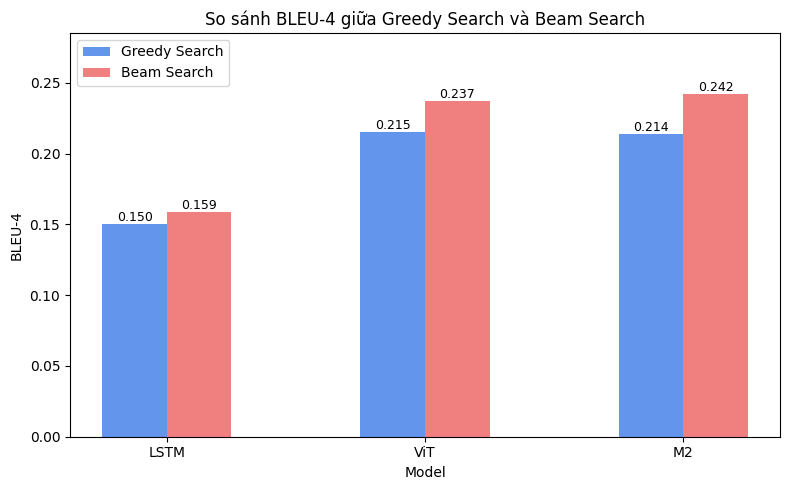

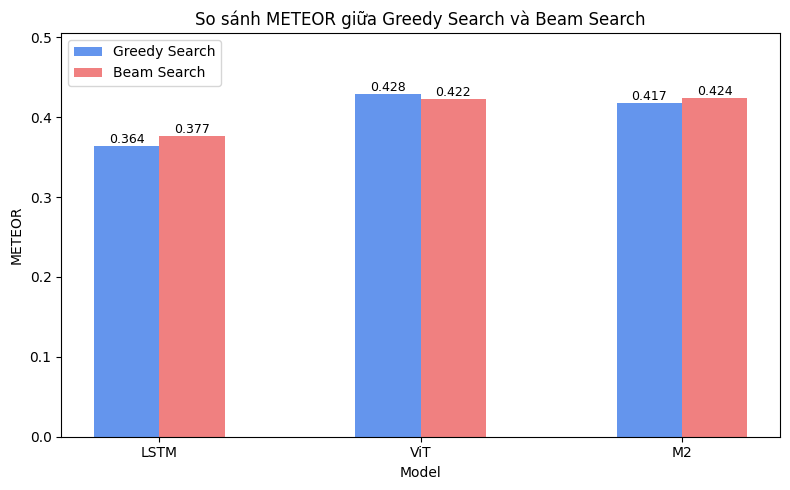

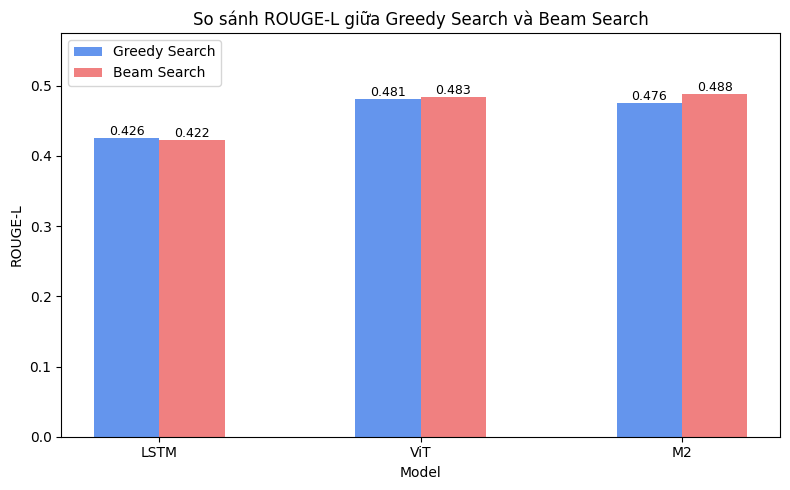

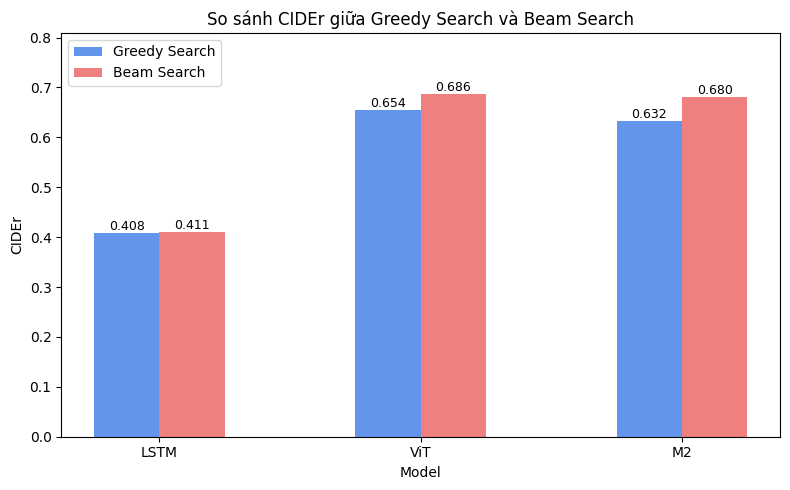

In [ ]:
metrics = ["BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]

for metric in metrics:
    plot_metric_comparison(df, metric)

# 8. Đánh giá mức độ hội tụ của mô hình

In [ ]:
# Đọc file logs của train
import re
import matplotlib.pyplot as plt

def plot_history_train_log(log_path):
  '''
  Vẽ đồ thị loss của train và val
  '''
  epochs = []
  train_losses = []
  val_losses = []

  pattern = r"Epoch \[(\d+)\] - Train Loss: ([\d.]+) \| Val Loss: ([\d.]+)"

  with open(log_path, "r", encoding="utf-8") as f:
    for line in f:
      match = re.search(pattern, line)
      if match:
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

  plt.figure(figsize=(8, 5))
  plt.plot(epochs, train_losses, marker="o", label="Train Loss")
  plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Train Loss vs Validation Loss")
  plt.legend()
  plt.grid(True)
  plt.show()

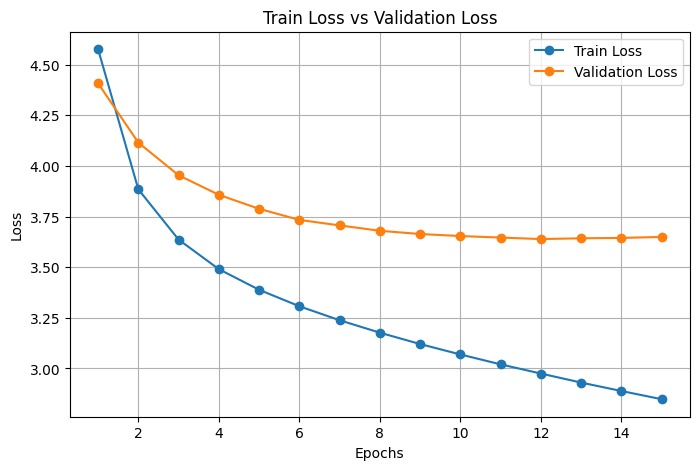

In [ ]:
# đồ thị của mô hình lstm
lstm_log_path = "experiments/logs/baseline_lstm_run1/train_20260518_032148.log"
plot_history_train_log(lstm_log_path)

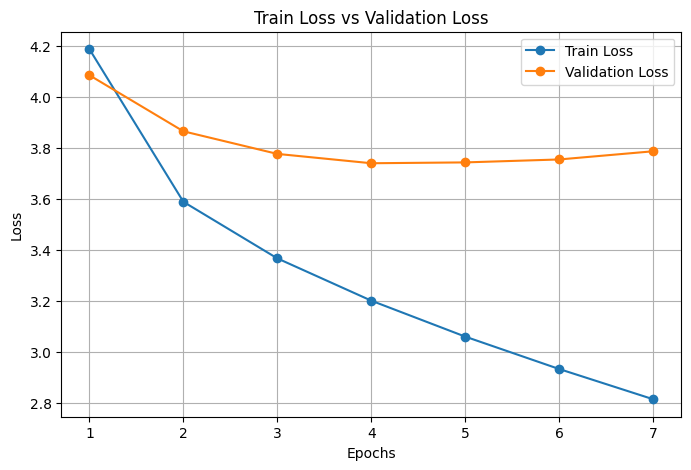

In [ ]:
# đồ thị của mô hình m2_transformer
m2_transformer_log_path = "experiments/logs/m2_transformer_run1/train_20260518_141446.log"
plot_history_train_log(m2_transformer_log_path)

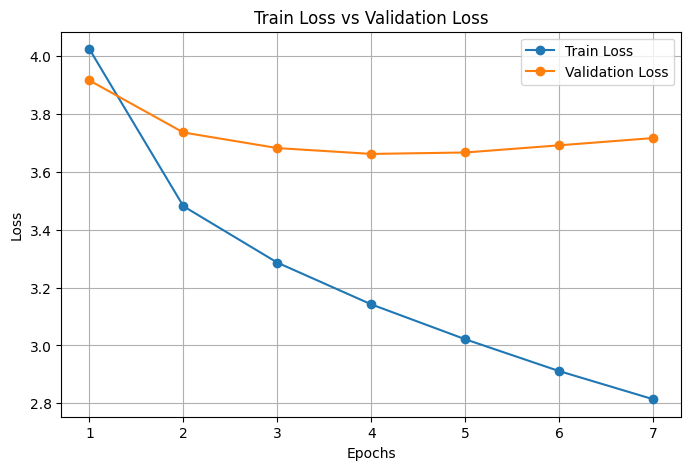

In [ ]:
# đồ thị của mô hình vit_transformer
vit_transformer_log_path = "experiments/logs/vit_transformer_v1/train_20260518_084511.log"
plot_history_train_log(vit_transformer_log_path)